#Transformer_semenctics_features_extraction#

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import numpy as np

# Step 1: Define your custom class labels
# animal_labels =# Test Classes (Unseen)
# test_classes = [
#     "chimpanzee",
#     "giant panda",
#     "hippopotamus",
#     "humpback whale",
#     "leopard",
#     "persian cat",
#     "pig",
#     "raccoon",
#     "rat",
#     "seal"
# ]

#Training Classes (Seen)
animal_labels = [
    "polar bear", "blue whale", "bobcat", "cow", "dolphin", "gorilla", "killer whale", "lion",
    "monkey", "mouse",
    "ox",
    "rabbit",
    "rhinoceros",
    "siamese cat",
    "skunk",
    "squirrel",
    "tiger",#
    "walrus",
    "chimpanzee",
    "giant panda",
    "hippopotamus",
    "humpback whale",
    "leopard",
    "persian cat",
    "pig",
    "raccoon",
    "rat",
    "seal"
]


animal_labels = list(dict.fromkeys(animal_labels))

# Step 2: Load transformer and encode
# transformer_model = SentenceTransformer('all-MiniLM-L6-v2')
transformer_model = SentenceTransformer('all-MiniLM-L6-v2')
animal_embeddings_384d = transformer_model.encode(animal_labels, convert_to_numpy=True)

# Step 3: Normalize the 384-d vectors
animal_embeddings_normalized = normalize(animal_embeddings_384d, axis=1)

# Step 4: Build index-to-vector mapping
label_index_to_vector = {
    idx: animal_embeddings_normalized[idx]
    for idx in range(len(animal_labels))
}


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_top_similar_animals(reference_idx, vector_dict, top_n=15):
    reference_vec = vector_dict[reference_idx]
    similarity_scores = []

    for idx, vec in vector_dict.items():
        if idx != reference_idx:
            sim = 1 - cosine(reference_vec, vec)
            similarity_scores.append((idx, sim))

    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    return similarity_scores[:top_n]

# Example: Find top 10 most similar to 'blue whale' (index 0)
top_similar = get_top_similar_animals(2, label_index_to_vector, top_n=20)

print(f"Most similar to '{animal_labels[2]}':")
for idx, score in top_similar:
    print(f"  {animal_labels[idx]} - similarity: {score:.4f}")


Most similar to 'bobcat':
  rabbit - similarity: 0.4130
  polar bear - similarity: 0.4103
  lion - similarity: 0.3923
  leopard - similarity: 0.3867
  pig - similarity: 0.3773
  humpback whale - similarity: 0.3654
  dolphin - similarity: 0.3517
  cow - similarity: 0.3480
  monkey - similarity: 0.3437
  walrus - similarity: 0.3413
  blue whale - similarity: 0.3359
  tiger - similarity: 0.3221
  killer whale - similarity: 0.3208
  gorilla - similarity: 0.3105
  squirrel - similarity: 0.3044
  rat - similarity: 0.2990
  persian cat - similarity: 0.2898
  giant panda - similarity: 0.2863
  chimpanzee - similarity: 0.2735
  siamese cat - similarity: 0.2655


# Disease similairty #

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import numpy as np

# Step 1: Define your custom class labels
# animal_labels =# Test Classes (Unseen)
# test_classes = [
#     "chimpanzee",
#     "giant panda",
#     "hippopotamus",
#     "humpback whale",
#     "leopard",
#     "persian cat",
#     "pig",
#     "raccoon",
#     "rat",
#     "seal"
# ]

#Training Classes (Seen)
animal_labels = [
    "Infiltration", "Effusion", "Atelectasis", "Nodule", "Mass", "Pneumothorax", "Consolidation", "Pleural_Thickening",
    "Cardiomegaly", "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia",
    "Hernia"

]


animal_labels = list(dict.fromkeys(animal_labels))

# Step 2: Load transformer and encode
# transformer_model = SentenceTransformer('all-MiniLM-L6-v2')
transformer_model = SentenceTransformer('all-mpnet-base-v2')
animal_embeddings_384d = transformer_model.encode(animal_labels, convert_to_numpy=True)

# Step 3: Normalize the 384-d vectors
animal_embeddings_normalized = normalize(animal_embeddings_384d, axis=1)

# Step 4: Build index-to-vector mapping
label_index_to_vector = {
    idx: animal_embeddings_normalized[idx]
    for idx in range(len(animal_labels))
}


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_top_similar_animals(reference_idx, vector_dict, top_n=5):
    reference_vec = vector_dict[reference_idx]
    similarity_scores = []

    for idx, vec in vector_dict.items():
        if idx != reference_idx:
            sim = 1 - cosine(reference_vec, vec)
            similarity_scores.append((idx, sim))

    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    return similarity_scores[:top_n]


for i,v in enumerate(animal_labels):

  # Example: Find top 10 most similar to 'blue whale' (index 0)
  top_similar = get_top_similar_animals(i, label_index_to_vector, top_n=5)

  print(f"Most similar to '{animal_labels[i]}':")
  for idx, score in top_similar:
      print(f"  {animal_labels[idx]} - similarity: {score:.4f}")
  print("::")


Most similar to 'Infiltration':
  Effusion - similarity: 0.4650
  Edema - similarity: 0.2953
  Consolidation - similarity: 0.2729
  Pneumonia - similarity: 0.2635
  Cardiomegaly - similarity: 0.2383
::
Most similar to 'Effusion':
  Infiltration - similarity: 0.4650
  Edema - similarity: 0.4621
  Pneumothorax - similarity: 0.4137
  Emphysema - similarity: 0.4115
  Atelectasis - similarity: 0.3730
::
Most similar to 'Atelectasis':
  Fibrosis - similarity: 0.4894
  Cardiomegaly - similarity: 0.4721
  Emphysema - similarity: 0.4431
  Pneumothorax - similarity: 0.4428
  Edema - similarity: 0.4261
::
Most similar to 'Nodule':
  Pneumothorax - similarity: 0.4673
  Emphysema - similarity: 0.4225
  Hernia - similarity: 0.4217
  Pleural_Thickening - similarity: 0.4210
  Edema - similarity: 0.4184
::
Most similar to 'Mass':
  Consolidation - similarity: 0.2385
  Cardiomegaly - similarity: 0.2269
  Effusion - similarity: 0.2048
  Infiltration - similarity: 0.1873
  Emphysema - similarity: 0.1593
:

# Medical Transformer

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import numpy as np

# Step 1: Define your custom class labels
# animal_labels =# Test Classes (Unseen)
# test_classes = [
#     "chimpanzee",
#     "giant panda",
#     "hippopotamus",
#     "humpback whale",
#     "leopard",
#     "persian cat",
#     "pig",
#     "raccoon",
#     "rat",
#     "seal"
# ]

#Training Classes (Seen)
animal_labels = [
    "Infiltration", "Effusion", "Atelectasis", "Nodule", "Mass", "Pneumothorax", "Consolidation", "Pleural_Thickening",
    "Cardiomegaly", "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia",
    "Hernia"

]


animal_labels = list(dict.fromkeys(animal_labels))

# Step 2: Load transformer and encode
# transformer_model = SentenceTransformer('all-MiniLM-L6-v2')
transformer_model = SentenceTransformer('pritamdeka/S-Scibert-snli-multinli-stsb')
animal_embeddings_384d = transformer_model.encode(animal_labels, convert_to_numpy=True)

# Step 3: Normalize the 384-d vectors
animal_embeddings_normalized = normalize(animal_embeddings_384d, axis=1)

# Step 4: Build index-to-vector mapping
label_index_to_vector = {
    idx: animal_embeddings_normalized[idx]
    for idx in range(len(animal_labels))
}


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_top_similar_animals(reference_idx, vector_dict, top_n=5):
    reference_vec = vector_dict[reference_idx]
    similarity_scores = []

    for idx, vec in vector_dict.items():
        if idx != reference_idx:
            sim = 1 - cosine(reference_vec, vec)
            similarity_scores.append((idx, sim))

    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    return similarity_scores[:top_n]


for i,v in enumerate(animal_labels):

  # Example: Find top 10 most similar to 'blue whale' (index 0)
  top_similar = get_top_similar_animals(i, label_index_to_vector, top_n=5)

  print(f"Most similar to '{animal_labels[i]}':")
  for idx, score in top_similar:
      print(f"  {animal_labels[idx]} - similarity: {score:.4f}")
  print("::")


Most similar to 'Infiltration':
  Effusion - similarity: 0.5560
  Consolidation - similarity: 0.5005
  Edema - similarity: 0.4876
  Fibrosis - similarity: 0.3827
  Nodule - similarity: 0.3736
::
Most similar to 'Effusion':
  Infiltration - similarity: 0.5560
  Edema - similarity: 0.5139
  Pleural_Thickening - similarity: 0.4643
  Mass - similarity: 0.4167
  Pneumothorax - similarity: 0.3130
::
Most similar to 'Atelectasis':
  Emphysema - similarity: 0.5237
  Pneumonia - similarity: 0.4631
  Pneumothorax - similarity: 0.4557
  Edema - similarity: 0.3936
  Pleural_Thickening - similarity: 0.3717
::
Most similar to 'Nodule':
  Fibrosis - similarity: 0.4647
  Infiltration - similarity: 0.3736
  Emphysema - similarity: 0.3593
  Mass - similarity: 0.3570
  Edema - similarity: 0.3520
::
Most similar to 'Mass':
  Effusion - similarity: 0.4167
  Consolidation - similarity: 0.3700
  Nodule - similarity: 0.3570
  Infiltration - similarity: 0.3553
  Edema - similarity: 0.3003
::
Most similar to 'P

#Using BioBERT

In [ ]:
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import normalize
import torch
import numpy as np

# Step 1: Biomedical labels
animal_labels = [
    "Infiltration", "Effusion", "Atelectasis", "Nodule", "Mass", "Pneumothorax",
    "Consolidation", "Pleural Thickening", "Cardiomegaly", "Emphysema",
    "Edema", "Fibrosis", "Pneumonia", "Hernia"
]
animal_labels = list(dict.fromkeys(animal_labels))  # remove duplicates

# Step 2: Load Bio_ClinicalBERT
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Step 3: Encode labels into embeddings
def get_embeddings(text_list):
    inputs = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    # Mean pooling over token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).numpy()
    return embeddings

animal_embeddings = get_embeddings(animal_labels)

# Step 4: Normalize embeddings
animal_embeddings_normalized = normalize(animal_embeddings, axis=1)

# Step 5: Map index to vector
label_index_to_vector = {
    idx: animal_embeddings_normalized[idx]
    for idx in range(len(animal_labels))
}

print("✅ Bio_ClinicalBERT embeddings ready!")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


✅ Bio_ClinicalBERT embeddings ready!


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_top_similar_animals(reference_idx, vector_dict, top_n=5):
    # Stack vectors into a matrix
    all_vectors = np.array(list(vector_dict.values()))
    reference_vec = all_vectors[reference_idx].reshape(1, -1)

    # Compute cosine similarity for this reference
    sims = cosine_similarity(reference_vec, all_vectors)[0]

    # Exclude self by setting its similarity to -inf
    sims[reference_idx] = -np.inf

    # Get top_n indices
    top_indices = np.argsort(sims)[::-1][:top_n]
    return [(idx, sims[idx]) for idx in top_indices]

# Loop over each biomedical label
for i, v in enumerate(animal_labels):
    top_similar = get_top_similar_animals(i, label_index_to_vector, top_n=5)
    print(f"Most similar to '{animal_labels[i]}':")
    for idx, score in top_similar:
        print(f"  {animal_labels[idx]} - similarity: {score:.4f}")
    print("::")


Most similar to 'Infiltration':
  Nodule - similarity: 0.9023
  Mass - similarity: 0.8913
  Pleural Thickening - similarity: 0.8911
  Atelectasis - similarity: 0.8908
  Effusion - similarity: 0.8750
::
Most similar to 'Effusion':
  Infiltration - similarity: 0.8750
  Atelectasis - similarity: 0.8651
  Pleural Thickening - similarity: 0.8608
  Pneumothorax - similarity: 0.8607
  Emphysema - similarity: 0.8363
::
Most similar to 'Atelectasis':
  Infiltration - similarity: 0.8908
  Pleural Thickening - similarity: 0.8902
  Effusion - similarity: 0.8651
  Nodule - similarity: 0.8557
  Emphysema - similarity: 0.8492
::
Most similar to 'Nodule':
  Mass - similarity: 0.9055
  Infiltration - similarity: 0.9023
  Fibrosis - similarity: 0.8710
  Hernia - similarity: 0.8629
  Atelectasis - similarity: 0.8557
::
Most similar to 'Mass':
  Consolidation - similarity: 0.9252
  Pneumonia - similarity: 0.9076
  Nodule - similarity: 0.9055
  Infiltration - similarity: 0.8913
  Hernia - similarity: 0.846

#SciBERT model from Hugging Face#

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import numpy as np

# Step 1: Define your custom class labels
animal_labels = [
    "polar bear", "blue whale", "bobcat", "cow", "dolphin", "gorilla", "killer whale", "lion",
    "monkey", "mouse",
    "ox",
    "rabbit",
    "rhinoceros",
    "siamese cat",
    "skunk",
    "squirrel",
    "tiger",
    "walrus",
    "chimpanzee",
    "giant panda",
    "hippopotamus",
    "humpback whale",
    "leopard",
    "persian cat",
    "pig",
    "raccoon",
    "rat",
    "seal"
]


# animal_labels = [
#     "chimpanzee",
#     "giant panda",
#     "hippopotamus",
#     "humpback whale",
#     "leopard",
#     "persian cat",
#     "pig",
#     "raccoon",
#     "rat",
#     "seal"
# ]
# Remove duplicates if any
animal_labels = list(dict.fromkeys(animal_labels))

# Step 2: Load SciBERT model from Hugging Face
# This variant is fine-tuned for sentence similarity tasks
transformer_model = SentenceTransformer('pritamdeka/S-Scibert-snli-multinli-stsb')

# Step 3: Encode labels into 768-d embeddings
animal_embeddings = transformer_model.encode(animal_labels, convert_to_numpy=True)

# Step 4: Normalize the embeddings
animal_embeddings_normalized = normalize(animal_embeddings, axis=1)

# Step 5: Build index-to-vector mapping
label_index_to_vector = {
    idx: animal_embeddings_normalized[idx]
    for idx in range(len(animal_labels))
}

# Function to get top-N most similar animals
def get_top_similar_animals(reference_idx, vector_dict, top_n=15):
    reference_vec = vector_dict[reference_idx]
    similarity_scores = []

    for idx, vec in vector_dict.items():
        if idx != reference_idx:
            sim = 1 - cosine(reference_vec, vec)
            similarity_scores.append((idx, sim))

    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    return similarity_scores[:top_n]

# Example: Find top 20 most similar to 'bobcat' (index 2)
top_similar = get_top_similar_animals(16, label_index_to_vector, top_n=20)

print(f"Most similar to '{animal_labels[16]}':")
for idx, score in top_similar:
    print(f"  {animal_labels[idx]} - similarity: {score:.4f}")


Most similar to 'tiger':
  gorilla - similarity: 0.2303
  ox - similarity: 0.2031
  dolphin - similarity: 0.1927
  lion - similarity: 0.1835
  monkey - similarity: 0.1636
  rat - similarity: 0.1564
  persian cat - similarity: 0.1427
  cow - similarity: 0.1409
  chimpanzee - similarity: 0.1313
  seal - similarity: 0.1018
  squirrel - similarity: 0.1009
  blue whale - similarity: 0.0880
  pig - similarity: 0.0850
  walrus - similarity: 0.0831
  hippopotamus - similarity: 0.0824
  siamese cat - similarity: 0.0823
  leopard - similarity: 0.0775
  skunk - similarity: 0.0637
  polar bear - similarity: 0.0525
  mouse - similarity: 0.0466


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import numpy as np

# Step 1: Define your fixed animal label set
animal_labels = [
    "chimpanzee",
    "giant panda",
    "hippopotamus",
    "humpback whale",
    "leopard",
    "persian cat",
    "pig",
    "raccoon",
    "rat",
    "seal"
]

# Step 2: Load SciBERT model
transformer_model = SentenceTransformer('pritamdeka/S-Scibert-snli-multinli-stsb')

# Step 3: Encode & normalize the known labels
animal_embeddings = transformer_model.encode(animal_labels, convert_to_numpy=True)
animal_embeddings_normalized = normalize(animal_embeddings, axis=1)

label_index_to_vector = {idx: animal_embeddings_normalized[idx] for idx in range(len(animal_labels))}

# Function to get similarity with ANY query term
def get_top_similar_animals(query, vector_dict, labels, model, top_n=5):
    # Encode & normalize the query
    query_vec = model.encode([query], convert_to_numpy=True)
    query_vec = normalize(query_vec, axis=1)[0]

    # Calculate similarity with all animals
    similarity_scores = []
    for idx, vec in vector_dict.items():
        sim = 1 - cosine(query_vec, vec)
        similarity_scores.append((labels[idx], sim))

    # Sort and return top N
    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    return query, similarity_scores[:top_n]

# Example: query term not in the list
ref_label, top_similar = get_top_similar_animals("tiger", label_index_to_vector, animal_labels, transformer_model, top_n=10)

print(f"Most similar to '{ref_label}':")
for label, score in top_similar:
    print(f"  {label} - similarity: {score:.4f}")


Most similar to 'tiger':
  rat - similarity: 0.1564
  persian cat - similarity: 0.1427
  chimpanzee - similarity: 0.1313
  seal - similarity: 0.1018
  pig - similarity: 0.0850
  hippopotamus - similarity: 0.0824
  leopard - similarity: 0.0775
  giant panda - similarity: 0.0423
  raccoon - similarity: 0.0181
  humpback whale - similarity: -0.0229


# To find the similarity using transformer by uploading csv#

In [ ]:
import pandas as pd

# Load your CSV file (replace with your actual path)
df = pd.read_csv("prediction_results_10images_per_class.csv")

# Clean the pred_image_label column: remove underscores
df['cleaned_label'] = df['pred_image_label'].str.replace("_", " ")

# Encode cleaned labels using the same transformer
pred_embeddings = transformer_model.encode(df['cleaned_label'].tolist(), convert_to_numpy=True)
pred_embeddings_normalized = normalize(pred_embeddings, axis=1)

# Function to find top-N similar labels from your `animal_labels` embeddings
def get_top_similar_for_vector(input_vector, animal_vectors, animal_names, top_n=5):
    scores = []
    for idx, vec in enumerate(animal_vectors):
        sim = 1 - cosine(input_vector, vec)
        scores.append((animal_names[idx], sim))
    scores.sort(key=lambda x: x[1], reverse=True)
    return [name for name, _ in scores[:top_n]]

# Apply similarity search row-wise
top_5_results = []
top_10_results = []

for vec in pred_embeddings_normalized:
    top5 = get_top_similar_for_vector(vec, animal_embeddings_normalized, animal_labels, top_n=5)
    top10 = get_top_similar_for_vector(vec, animal_embeddings_normalized, animal_labels, top_n=10)
    top_5_results.append(", ".join(top5))
    top_10_results.append(", ".join(top10))

# Add similarity columns to the DataFrame
df['top_5_similar_animals'] = top_5_results
df['top_10_similar_animals'] = top_10_results

# Save or display the new DataFrame
df.to_csv("output_with_similarity.csv", index=False)
print("Processed DataFrame saved as 'output_with_similarity.csv'")


Processed DataFrame saved as 'output_with_similarity.csv'


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
from collections import defaultdict

# Initialize accuracy tracking
top5_correct = defaultdict(int)
top10_correct = defaultdict(int)
total_per_class = defaultdict(int)

# Loop over each row to compare image_label (actual) with top-5 and top-10 predictions
for _, row in df.iterrows():
    true_label = row['image_label'].replace("_", " ").strip()  # Normalize to match embedding format

    # Parse top-5 and top-10 predictions from the CSV columns
    top5_preds = [label.strip() for label in row['top_5_similar_animals'].split(',')]
    top10_preds = [label.strip() for label in row['top_10_similar_animals'].split(',')]

    total_per_class[true_label] += 1

    if true_label in top5_preds:
        top5_correct[true_label] += 1
    if true_label in top10_preds:
        top10_correct[true_label] += 1

# Compute accuracy per class
print("Top-5 Accuracy per Class:")
top5_acc = {}
for label in total_per_class:
    acc = top5_correct[label] / total_per_class[label]
    top5_acc[label] = acc
    print(f"  {label:<20}: {acc:.2f}")

print("\nTop-10 Accuracy per Class:")
top10_acc = {}
for label in total_per_class:
    acc = top10_correct[label] / total_per_class[label]
    top10_acc[label] = acc
    print(f"  {label:<20}: {acc:.2f}")

# Overall average accuracy
avg_top5 = sum(top5_correct.values()) / sum(total_per_class.values())
avg_top10 = sum(top10_correct.values()) / sum(total_per_class.values())

print(f"\nOverall Top-5 Accuracy:  {avg_top5:.2f}")
print(f"Overall Top-10 Accuracy: {avg_top10:.2f}")


Top-5 Accuracy per Class:
  chimpanzee          : 0.80
  giant panda         : 0.00
  hippopotamus        : 0.00
  humpback whale      : 1.00
  leopard             : 1.00
  persian cat         : 1.00
  pig                 : 0.50
  raccoon             : 0.40
  rat                 : 1.00
  seal                : 0.00

Top-10 Accuracy per Class:
  chimpanzee          : 0.80
  giant panda         : 0.30
  hippopotamus        : 0.30
  humpback whale      : 1.00
  leopard             : 1.00
  persian cat         : 1.00
  pig                 : 0.50
  raccoon             : 0.80
  rat                 : 1.00
  seal                : 0.00

Overall Top-5 Accuracy:  0.57
Overall Top-10 Accuracy: 0.67


#final code to find similarity using Transformer#

In [ ]:
import os
import glob
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import torch

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Get class names from unseen folder structure (you can adjust path as needed)
image_class = [
    "chimpanzee",
    "giant panda",
    "hippopotamus",
    "humpback whale",
    "leopard",
    "persian cat",
    "pig",
    "raccoon",
    "rat",
    "seal"
]


# Index mapping (optional, not used directly here)
idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}
words = list(idx_to_unseen_class.values())  # Class names

# Encode class labels
embeddings = model.encode(words, convert_to_tensor=True)

# Path to your CSV file (update this path to your actual CSV file)
csv_file_path = "prediction_results_10images_per_class.csv"
df = pd.read_csv(csv_file_path)

# Clean pred_image_label column by removing underscores
df['cleaned_pred_label'] = df['pred_image_label'].str.replace('_', ' ', regex=False)

# Similarity processing
similar_wds = []

for _, row in df.iterrows():
    query_label = row['cleaned_pred_label']

    # Encode predicted label
    query_embedding = model.encode(query_label, convert_to_tensor=True)

    # Compute cosine similarity
    cosine_scores = util.cos_sim(query_embedding, embeddings)

    # Get top-5 most similar class names
    top_results = torch.topk(cosine_scores[0], k=5)

    top_labels = [words[idx] for idx in top_results.indices]
    top_scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    # Store as a tuple in a new column
    similar_wds.append((top_labels, top_scores))

# Add new column with results
df['top5_similar_labels_with_scores'] = similar_wds

# Save the updated CSV
output_csv_path = "output_with_similarity_only_test_classes.csv"
df.to_csv(output_csv_path, index=False)
print(f"✅ Done! Saved to '{output_csv_path}'")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


✅ Done! Saved to 'output_with_similarity_only_test_classes.csv'


#Final output for 10 images from each unseen class #
#output_with_similarity_only_test_classes.csv--- Output file with transformer similarity result#

# Visual Similarty is calculated based on hybrid feature approach#


In [ ]:
import pandas as pd
import ast

# Load your CSV
df = pd.read_csv("output_with_similarity_only_test_classes.csv")  # Change if needed

print(df.columns.tolist())


# Clean actual labels
df['image_label'] = df['image_label'].str.replace("_", " ").str.lower().str.strip()

# Parse top5 labels with scores
def extract_labels(top5_str):
    try:
        parsed = ast.literal_eval(top5_str)
        return [label.lower().strip() for label in parsed[0]]  # First part is labels
    except:
        return []

df['top_5_predicted'] = df['top5_similar_labels_with_scores'].apply(extract_labels)

# Compute hit (True if actual label is in top-5)
df['top5_hit'] = df.apply(lambda row: row['image_label'] in row['top_5_predicted'], axis=1)

# Compute per-class accuracy
accuracy_per_class = df.groupby('image_label')['top5_hit'].agg(['sum', 'count']).reset_index()
accuracy_per_class['top5_accuracy (%)'] = round((accuracy_per_class['sum'] / accuracy_per_class['count']) * 100, 2)
accuracy_per_class.rename(columns={'sum': 'correct', 'count': 'total'}, inplace=True)

# Average accuracy
average_top5_accuracy = round(accuracy_per_class['top5_accuracy (%)'].mean(), 2)

# Output
print("\nTop-5 Accuracy per Class:")
print(accuracy_per_class)

print(f"\nAverage Top-5 Accuracy: {average_top5_accuracy:.2f}%")

# Optional: Save
accuracy_per_class.to_csv("top5_accuracy_summary.csv", index=False)


['image_path', 'image_label', 'pred_image_label', 'act_label', 'pred_label', 'cleaned_pred_label', 'top5_similar_labels_with_scores']

Top-5 Accuracy per Class:
      image_label  correct  total  top5_accuracy (%)
0      chimpanzee        8     10               80.0
1     giant panda        8     10               80.0
2    hippopotamus        3     10               30.0
3  humpback whale       10     10              100.0
4         leopard       10     10              100.0
5     persian cat       10     10              100.0
6             pig        8     10               80.0
7         raccoon        9     10               90.0
8             rat       10     10              100.0
9            seal        1     10               10.0

Average Top-5 Accuracy: 77.00%


#Now checking the output for images of unseen classes#

In [ ]:
import os
import glob
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import torch

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Get class names from unseen folder structure (you can adjust path as needed)
image_class = [
    "chimpanzee",
    "giant panda",
    "hippopotamus",
    "humpback whale",
    "leopard",
    "persian cat",
    "pig",
    "raccoon",
    "rat",
    "seal"
]


# Index mapping (optional, not used directly here)
idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}
words = list(idx_to_unseen_class.values())  # Class names

# Encode class labels
embeddings = model.encode(words, convert_to_tensor=True)

# Path to your CSV file (update this path to your actual CSV file)
csv_file_path = r"/content/prediction_results_Resnet_GLCM_AWA2_seal"
df = pd.read_csv(csv_file_path)

# Clean pred_image_label column by removing underscores
df['cleaned_pred_label'] = df['pred_image_label'].str.replace('_', ' ', regex=False)

# Similarity processing
similar_wds = []

for _, row in df.iterrows():
    query_label = row['cleaned_pred_label']

    # Encode predicted label
    query_embedding = model.encode(query_label, convert_to_tensor=True)

    # Compute cosine similarity
    cosine_scores = util.cos_sim(query_embedding, embeddings)

    # Get top-5 most similar class names
    top_results = torch.topk(cosine_scores[0], k=5)

    top_labels = [words[idx] for idx in top_results.indices]
    top_scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    # Store as a tuple in a new column
    similar_wds.append((top_labels, top_scores))

# Add new column with results
df['top5_similar_labels_with_scores'] = similar_wds

# Save the updated CSV
output_csv_path = "prediction_results_Resnet_GLCM_AWA2_seal_output_with_similarity.csv"
df.to_csv(output_csv_path, index=False)
print(f"✅ Done! Saved to '{output_csv_path}'")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


✅ Done! Saved to 'prediction_results_Resnet_GLCM_AWA2_seal_output_with_similarity.csv'


In [ ]:
import pandas as pd
import ast

# Load your CSV
df = pd.read_csv("prediction_results_Resnet_GLCM_AWA2_seal_output_with_similarity.csv")  # Change if needed

print(df.columns.tolist())


# Clean actual labels
df['image_label'] = df['image_label'].str.replace("_", " ").str.lower().str.strip()

# Parse top5 labels with scores
def extract_labels(top5_str):
    try:
        parsed = ast.literal_eval(top5_str)
        return [label.lower().strip() for label in parsed[0]]  # First part is labels
    except:
        return []

df['top_5_predicted'] = df['top5_similar_labels_with_scores'].apply(extract_labels)

# Compute hit (True if actual label is in top-5)
df['top5_hit'] = df.apply(lambda row: row['image_label'] in row['top_5_predicted'], axis=1)

# Compute per-class accuracy
accuracy_per_class = df.groupby('image_label')['top5_hit'].agg(['sum', 'count']).reset_index()
accuracy_per_class['top5_accuracy (%)'] = round((accuracy_per_class['sum'] / accuracy_per_class['count']) * 100, 2)
accuracy_per_class.rename(columns={'sum': 'correct', 'count': 'total'}, inplace=True)

# Average accuracy
average_top5_accuracy = round(accuracy_per_class['top5_accuracy (%)'].mean(), 2)

# Output
print("\nTop-5 Accuracy per Class:")
print(accuracy_per_class)

print(f"\nAverage Top-5 Accuracy: {average_top5_accuracy:.2f}%")

# Optional: Save
accuracy_per_class.to_csv("prediction_results_Resnet_GLCM_AWA2_seal_accuracy_summary.csv", index=False)


['image_path', 'image_label', 'pred_image_label', 'act_label', 'pred_label', 'cleaned_pred_label', 'top5_similar_labels_with_scores']

Top-5 Accuracy per Class:
  image_label  correct  total  top5_accuracy (%)
0        seal       95    988               9.62

Average Top-5 Accuracy: 9.62%


# Transfromer with Autoencoder#

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import numpy as np

# Step 1: Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 2: Define unseen class labels (from your image_class list)
image_class =  [
    "chimpanzee",
    "giant panda",
    "hippopotamus",
    "humpback whale",
    "leopard",
    "persian cat",
    "pig",
    "raccoon",
    "rat",
    "seal"
]

  # [
#     "polar bear", "blue whale", "bobcat", "cow", "dolphin", "gorilla", "killer whale", "lion",
#     "monkey", "mouse",
#     "ox",
#     "rabbit",
#     "rhinoceros",
#     "siamese cat",
#     "skunk",
#     "squirrel",
#     "tiger",#
#     "walrus",
#     "chimpanzee",
#     "giant panda",
#     "hippopotamus",
#     "humpback whale",
#     "leopard",
#     "persian cat",
#     "pig",
#     "raccoon",
#     "rat",
#     "seal"
# ]

  # [
#     "chimpanzee",
#     "giant panda",
#     "hippopotamus",
#     "humpback whale",
#     "leopard",
#     "persian cat",
#     "pig",
#     "raccoon",
#     "rat",
#     "seal"
# ]

# Step 3: Create index-to-class mapping (optional)
idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}
words = list(idx_to_unseen_class.values())

# Step 4: Encode class labels as embeddings
embeddings_tensor = model.encode(words, convert_to_tensor=True)
embeddings_np = embeddings_tensor.cpu().numpy()  # Convert tensor to numpy for processing
class_embeddings_normalized = normalize(embeddings_np, axis=1)

# Step 5: Build index-to-vector mapping
label_index_to_vector = {
    idx: class_embeddings_normalized[idx]
    for idx in range(len(words))
}


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os
from scipy.spatial.distance import cosine




def tune_autoencoder(input_dim, latent_dim):
    # Input layer
    input_layer = Input(shape=(input_dim,))

    # Sample Test 1
    # Encoder layers
    encoded = Dense(32, activation='relu')(input_layer)
    encoded = Dense(latent_dim, activation='relu')(encoded)

    # Decoder layers
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)

    # Autoencoder model
    autoencoder = Model(input_layer, decoded)

    # Encoder model
    encoder = Model(input_layer, encoded)

    # Compile the autoencoder
    autoencoder.compile(optimizer='adam', loss='mse')
    # autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return encoder, autoencoder

def find_similar_sentences(target_sentence_index, sentence_to_latent, top_n=10):
    target_latent = sentence_to_latent[target_sentence_index]
    similarities = []
    for index, latent in sentence_to_latent.items():
        if index != target_sentence_index:
            similarity = 1 - cosine(target_latent, latent)
            similarities.append((index, similarity))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

def predict_with_autoencoder(input_word_index, sentence_to_latent, top_n=5):
    # Find sentences similar to the first sentence
    similar_sentences = find_similar_sentences(input_word_index, sentence_to_latent, top_n=top_n)
    similar_words = [custom_sentences[index] for index, score in similar_sentences]
    return similar_words

#modifieid aurocncoder model#


In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Dropout

def tune_autoencoder(input_dim, latent_dim):
    # Input layer
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dropout(0.3)(encoded)  # Dropout added here
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(latent_dim, activation='relu')(encoded)

    # Decoder
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dropout(0.3)(decoded)  # Dropout added here
    decoded = Dense(64, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)

    # Autoencoder model
    autoencoder = Model(input_layer, decoded)

    # Encoder model
    encoder = Model(input_layer, encoded)

    # Compile the autoencoder
    autoencoder.compile(optimizer='adam', loss='mse')

    return encoder, autoencoder


In [ ]:
encoder, autoencoder = tune_autoencoder(384, 16)
print("encoder summary : ")
encoder.summary()
print("autoencoder summary : ")
autoencoder.summary()

encoder summary : 


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,248 (106.44 KB)

 Trainable params: 27,248 (106.44 KB)

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 384)            │        24,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,864 (214.31 KB)

 Trainable params: 54,864 (214.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
 # Assume animal_embeddings_normalized is your training input
encoder, autoencoder = tune_autoencoder(input_dim=384, latent_dim=16)  # adjust dimensions as needed

autoencoder.fit(
    animal_embeddings_normalized,
    animal_embeddings_normalized,
    epochs=500,
    batch_size=32,
    shuffle=True,
    validation_split=0.1
    # callbacks=[early_stopping]
)


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.2516 - val_loss: 0.2508
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 0.2512 - val_loss: 0.2504
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.2508 - val_loss: 0.2499
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.2504 - val_loss: 0.2494
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.2498 - val_loss: 0.2488
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.2493 - val_loss: 0.2481
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.2483 - val_loss: 0.2472
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.2474 - val_loss: 0.2462
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.2464 - val_loss: 0.2450
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.2450 - val_loss: 0.2436
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.2436 - val_loss: 0.2420
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.2425 - val_l

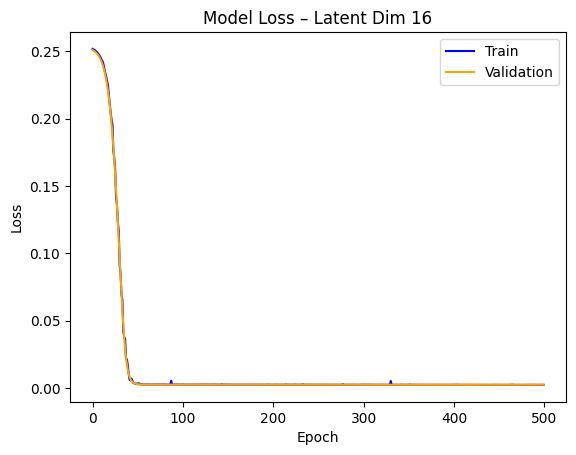

In [ ]:
import matplotlib.pyplot as plt

# Define latent dimension if not already defined
latent_dim = 16  # Change to the actual value you used

# Plot training and validation loss
plt.plot(autoencoder.history.history['loss'], color='blue')
plt.plot(autoencoder.history.history['val_loss'], color='orange')
plt.title(f'Model Loss – Latent Dim {latent_dim}')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# Save and display
plt.savefig("autoencoder_loss_plot.png", bbox_inches='tight')
plt.show()

In [ ]:
def predict_with_transformer(input_word, label_index_to_vector, label_list, transformer_model, top_n=10):
    """
    Predict top N most similar class labels to input_word based on cosine similarity.
    """
    input_embedding = transformer_model.encode([input_word], convert_to_numpy=True)
    input_embedding_normalized = input_embedding[0] / np.linalg.norm(input_embedding[0])

    similarities = []
    for idx, label_vector in label_index_to_vector.items():
        label = label_list[idx]
        if label.lower().replace('_', ' ') == input_word.lower().replace('_', ' '):
            continue  # Skip the input itself
        sim_score = 1 - cosine(input_embedding_normalized, label_vector)
        similarities.append((label, sim_score))

    top_similar = sorted(similarities, key=lambda x: x[1], reverse=True)[:top_n]
    return top_similar


In [ ]:
predicted_class_label='gorilla'

In [ ]:
predicted_class_label = 'gorilla'

if predicted_class_label in animal_labels:
    similar_words_transformer = predict_with_transformer(
        input_word=predicted_class_label,
        label_index_to_vector=label_index_to_vector,
        label_list=animal_labels,
        transformer_model=transformer_model,
        top_n=10
    )
    print(similar_words_transformer)
else:
    print(f"Label '{predicted_class_label}' not found in animal_labels.")


[('monkey', np.float32(0.6417081)), ('chimpanzee', np.float32(0.6233537)), ('lion', np.float32(0.51377547)), ('tiger', np.float32(0.5128764)), ('hippopotamus', np.float32(0.4889955)), ('squirrel', np.float32(0.46043557)), ('giant panda', np.float32(0.45725393)), ('dolphin', np.float32(0.43835765)), ('raccoon', np.float32(0.43780053)), ('cow', np.float32(0.42861867))]


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('prediction_results_10images_per_class.csv')

# Clean underscores in predicted labels
df['cleaned_label'] = df['pred_image_label'].str.replace('_', ' ')

# Function to find top 10 similar labels
def get_top_similar_labels(label):
    if label not in animal_labels:
        return "Label not found"
    top_similar = predict_with_transformer(
        input_word=label,
        label_index_to_vector=label_index_to_vector,
        label_list=animal_labels,
        transformer_model=transformer_model,
        top_n=10
    )
    return ", ".join([lbl for lbl, _ in top_similar])

# Apply the function
df['top_10_similar_labels'] = df['cleaned_label'].apply(get_top_similar_labels)

# Save the result
df.to_csv('prediction_results_10images_per_class_with_similar_labels.csv', index=False)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
import pandas as pd
import ast
from collections import defaultdict

# Load your CSV
df = pd.read_csv('prediction_results_10images_per_class_with_similar_labels.csv')

# Clean labels (remove underscores and normalize to lowercase)
df['cleaned_gt_label'] = df['image_label'].str.replace('_', ' ').str.lower().str.strip()
df['cleaned_pred_label'] = df['pred_image_label'].str.replace('_', ' ').str.lower().str.strip()

# Safely parse top_10_similar_labels, even if stored as comma-separated strings
def safe_parse_list(cell):
    try:
        # Try literal eval if possible
        return ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        # Fallback: split by commas if not a proper Python list
        return [item.strip().lower() for item in cell.split(',')] if isinstance(cell, str) else []

df['top_10_similar_labels'] = df['top_10_similar_labels'].apply(safe_parse_list)




In [ ]:
# Initialize accuracy trackers
class_correct = defaultdict(int)
class_total = defaultdict(int)

# Compute per-class accuracy
for _, row in df.iterrows():
    gt_label = row['cleaned_gt_label']
    top_10 = [label.strip().lower() for label in row['top_10_similar_labels']]

    class_total[gt_label] += 1
    if gt_label in top_10:
        class_correct[gt_label] += 1

# Calculate per-class accuracy
class_accuracies = {
    label: class_correct[label] / class_total[label]
    for label in class_total
}

# Calculate average accuracy
average_accuracy = sum(class_accuracies.values()) / len(class_accuracies)

# Print results
print("Per-Class Accuracy:")
for label, acc in class_accuracies.items():
    print(f"{label:20s}: {acc:.2f}")

print(f"\nOverall Average Accuracy: {average_accuracy:.2f}")

Per-Class Accuracy:
chimpanzee          : 0.80
giant panda         : 0.30
hippopotamus        : 0.30
humpback whale      : 1.00
leopard             : 1.00
persian cat         : 1.00
pig                 : 0.60
raccoon             : 0.80
rat                 : 1.00
seal                : 0.00

Overall Average Accuracy: 0.68


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv(r'/content/prediction_results_Resnet_GLCM_AWA2_seal')

# Clean underscores in predicted labels
df['cleaned_label'] = df['pred_image_label'].str.replace('_', ' ')

# Function to find top 10 similar labels
def get_top_similar_labels(label):
    if label not in animal_labels:
        return "Label not found"
    top_similar = predict_with_transformer(
        input_word=label,
        label_index_to_vector=label_index_to_vector,
        label_list=animal_labels,
        transformer_model=transformer_model,
        top_n=5
    )
    return ", ".join([lbl for lbl, _ in top_similar])

# Apply the function
df['top_10_similar_labels'] = df['cleaned_label'].apply(get_top_similar_labels)

# Save the result
df.to_csv('/content/prediction_results_Resnet_GLCM_AWA2_seal_with_autoencoder.csv', index=False)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
import pandas as pd
import ast
from collections import defaultdict

# Load your CSV
df = pd.read_csv('/content/prediction_results_Resnet_GLCM_AWA2_seal_with_autoencoder.csv')

# Clean labels (remove underscores and normalize to lowercase)
df['cleaned_gt_label'] = df['image_label'].str.replace('_', ' ').str.lower().str.strip()
df['cleaned_pred_label'] = df['pred_image_label'].str.replace('_', ' ').str.lower().str.strip()

# Safely parse top_10_similar_labels, even if stored as comma-separated strings
def safe_parse_list(cell):
    try:
        # Try literal eval if possible
        return ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        # Fallback: split by commas if not a proper Python list
        return [item.strip().lower() for item in cell.split(',')] if isinstance(cell, str) else []

df['top_10_similar_labels'] = df['top_10_similar_labels'].apply(safe_parse_list)




In [ ]:
# Initialize accuracy trackers
class_correct = defaultdict(int)
class_total = defaultdict(int)

# Compute per-class accuracy
for _, row in df.iterrows():
    gt_label = row['cleaned_gt_label']
    top_10 = [label.strip().lower() for label in row['top_10_similar_labels']]

    class_total[gt_label] += 1
    if gt_label in top_10:
        class_correct[gt_label] += 1

# Calculate per-class accuracy
class_accuracies = {
    label: class_correct[label] / class_total[label]
    for label in class_total
}

# Calculate average accuracy
average_accuracy = sum(class_accuracies.values()) / len(class_accuracies)

# Print results
print("Per-Class Accuracy:")
for label, acc in class_accuracies.items():
    print(f"{label:20s}: {acc:.2f}")

print(f"\nOverall Average Accuracy: {average_accuracy:.2f}")

Per-Class Accuracy:
seal                : 0.00

Overall Average Accuracy: 0.00


#Avarage Accuracy of AWA2 dataset with Autoecncoder#

In [ ]:
import pandas as pd
import glob
import os

# Set your folder path where all 10 CSVs are located
csv_folder = r'/content/Top_5_summary'  # e.g., r'D:\ZSL\accuracy_csvs'

# Get all CSV file paths
csv_files = glob.glob(os.path.join(csv_folder, '*.csv'))

# Read and combine all CSVs into one DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)

# Display the combined summary
print("Combined Summary:")
print(combined_df.head(10))

# Save combined summary if needed
combined_df.to_csv('combined_accuracy_Transformer_summary_AWA2.csv', index=False)


Combined Summary:
      image_label  correct  total  top5_accuracy (%)
0             pig      506    713              70.97
1            seal       95    988               9.62
2         leopard      719    720              99.86
3     persian cat      690    747              92.37
4      chimpanzee      675    728              92.72
5            seal       95    988               9.62
6     giant panda      822    874              94.05
7    hippopotamus      331    684              48.39
8         raccoon      424    512              82.81
9  humpback whale      709    709             100.00


In [ ]:
# Drop rows where 'correct', 'total', or 'top5_accuracy (%)' are NaN
cleaned_df = combined_df.dropna(subset=['correct', 'total', 'top5_accuracy (%)'])

# Convert columns to numeric if not already
cleaned_df['correct'] = pd.to_numeric(cleaned_df['correct'])
cleaned_df['total'] = pd.to_numeric(cleaned_df['total'])
cleaned_df['top5_accuracy (%)'] = pd.to_numeric(cleaned_df['top5_accuracy (%)'])

# Display cleaned summary
print("Cleaned Combined Summary:")
print(cleaned_df)


Cleaned Combined Summary:
      image_label  correct  total  top5_accuracy (%)
0             pig      506    713              70.97
1            seal       95    988               9.62
2         leopard      719    720              99.86
3     persian cat      690    747              92.37
4      chimpanzee      675    728              92.72
5            seal       95    988               9.62
6     giant panda      822    874              94.05
7    hippopotamus      331    684              48.39
8         raccoon      424    512              82.81
9  humpback whale      709    709             100.00


In [ ]:
average_top5_accuracy = combined_df['top5_accuracy (%)'].mean()
print(f"\nAverage Top-5 Accuracy: {average_top5_accuracy:.2f}%")



Average Top-5 Accuracy: 70.04%


In [ ]:
import pandas as pd
import ast
from collections import defaultdict

# Load your CSV
df = pd.read_csv('updated_with_similar_labels.csv')

# Clean image labels (remove underscores, lowercase, strip)
df['cleaned_gt_label'] = df['image_label'].str.replace('_', ' ').str.lower().str.strip()

# Ensure top_10_similar_labels is a proper list of cleaned strings
def safe_parse_and_clean(cell):
    try:
        parsed = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        parsed = cell.split(',') if isinstance(cell, str) else []

    # Clean each label: remove underscores, lowercase, strip
    return [str(label).replace('_', ' ').lower().strip() for label in parsed]

df['top_10_similar_labels'] = df['top_10_similar_labels'].apply(safe_parse_and_clean)

# Initialize accuracy trackers
class_correct = defaultdict(int)
class_total = defaultdict(int)

# Compute per-class accuracy
for _, row in df.iterrows():
    gt_label = row['cleaned_gt_label']
    top_10 = row['top_10_similar_labels']

    class_total[gt_label] += 1
    if gt_label in top_10:
        class_correct[gt_label] += 1

# Calculate per-class accuracy
class_accuracies = {
    label: class_correct[label] / class_total[label]
    for label in class_total
}

# Calculate average accuracy
average_accuracy = sum(class_accuracies.values()) / len(class_accuracies)

# Print results
print("Per-Class Accuracy:")
for label, acc in class_accuracies.items():
    print(f"{label:20s}: {acc:.2f}")

print(f"\nOverall Average Accuracy: {average_accuracy:.2f}")


Per-Class Accuracy:
chimpanzee          : 0.80
giant panda         : 0.80
hippopotamus        : 0.00
humpback whale      : 1.00
leopard             : 0.20
persian cat         : 1.00
pig                 : 0.80
raccoon             : 0.40
rat                 : 1.00
seal                : 0.10

Overall Average Accuracy: 0.61
